## Property Prices in Boston -1970



Welcome to Boston Massachusetts in the 1970s! Imagine you're working for a real estate development company. Your company wants to value any residential project before they start. You are tasked with building a model that can provide a price estimate based on a home's characteristics like:
* The number of rooms
* The distance to employment centres
* How rich or poor the area is
* How many students there are per teacher in local schools etc

<img src=https://i.imgur.com/WfUSSP7.png height=350>

To accomplish your task you will:

1. Analyse and explore the Boston house price data
2. Split your data for training and testing
3. Run a Multivariable Regression
4. Evaluate how your model's coefficients and residuals
5. Use data transformation to improve your model performance
6. Use your model to estimate a property price

### Import Statements


In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib.lines import lineStyles
from matplotlib.pyplot import xlabel

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

### Presentation



In [36]:
pd.options.display.float_format = '{:,.2f}'.format

### Load the dataset

In [37]:
df = pd.read_csv("boston.csv", index_col=0)     ## Index column is the same as the index
df.sample(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
454,9.51,0.00,18.10,0.00,0.71,6.73,94.10,2.50,24.00,666.00,20.20,6.68,18.71,14.90
100,0.15,0.00,8.56,0.00,0.52,6.73,79.90,2.78,5.00,384.00,20.90,394.76,9.42,27.50
2,0.03,0.00,7.07,0.00,0.47,7.18,61.10,4.97,2.00,242.00,17.80,392.83,4.03,34.70
441,9.72,0.00,18.10,0.00,0.74,6.41,97.20,2.07,24.00,666.00,20.20,385.96,19.52,17.10
372,8.27,0.00,18.10,1.00,0.67,5.88,89.60,1.13,24.00,666.00,20.20,347.88,8.88,50.00


### Initial checks

In [38]:
#### Checks 1 ( head, tail,, shape, data types, column names)
df.head()
df.tail()
df.shape            #(506 by 14)
df.columns          # all as codes
df.dtypes           # All data as floats

## No adjustments needed so far

CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD        float64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
PRICE      float64
dtype: object

In [39]:
#### Checks 2 missing values, column removals and duplicates

    #### Missing values
df.isna().sum()                                         # No  missing values

    #### Remove columns
                                                        #  no need to remove columns

    #### Checks for duplicates
df.duplicated(keep=False).value_counts()                # No duplicates since all are false


False    506
Name: count, dtype: int64

### Descriptive statistics

In [40]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.00,0.39,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.23,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


### Visualise the Data

**Challenge**: Having looked at some descriptive statistics, visualise the data for your model. Use [Seaborn's `.displot()`](https://seaborn.pydata.org/generated/seaborn.displot.html#seaborn.displot) to create a bar chart and superimpose the Kernel Density Estimate (KDE) for the following variables:
* PRICE: The home price in thousands.
* RM: the average number of rooms per owner unit.
* DIS: the weighted distance to the 5 Boston employment centres i.e., the estimated length of the commute.
* RAD: the index of accessibility to highways.

Try setting the `aspect` parameter to `2` for a better picture.

What do you notice in the distributions of the data?

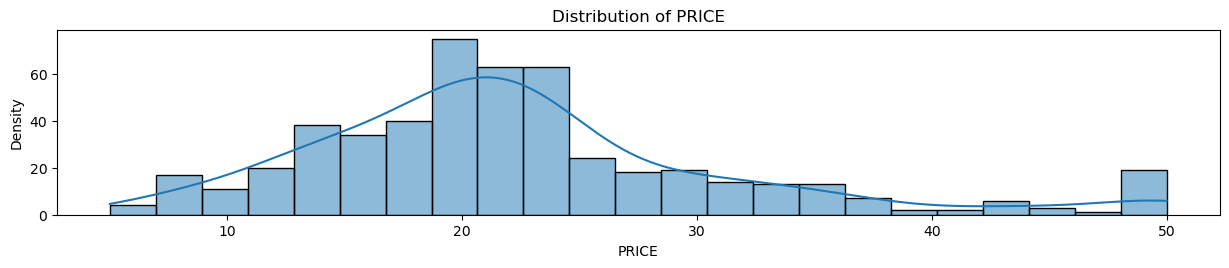

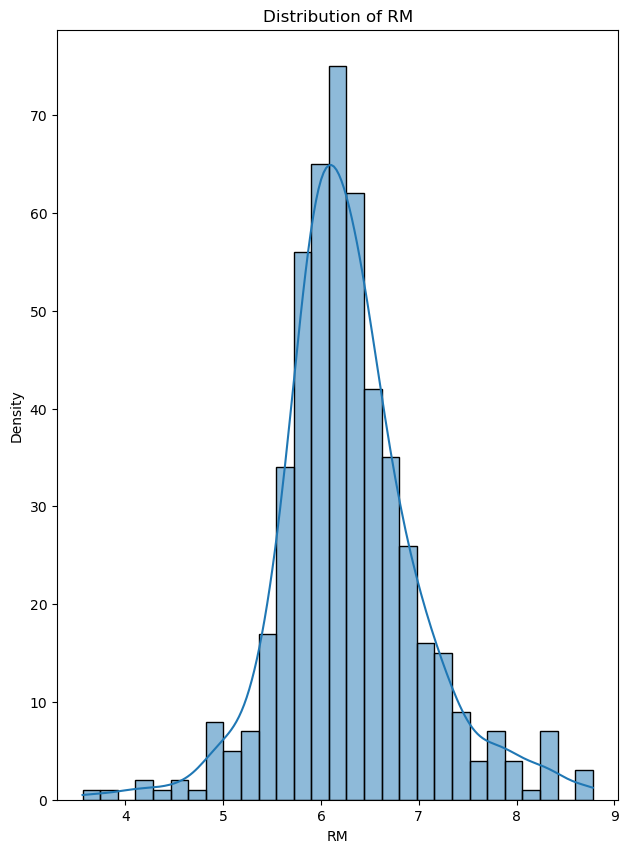

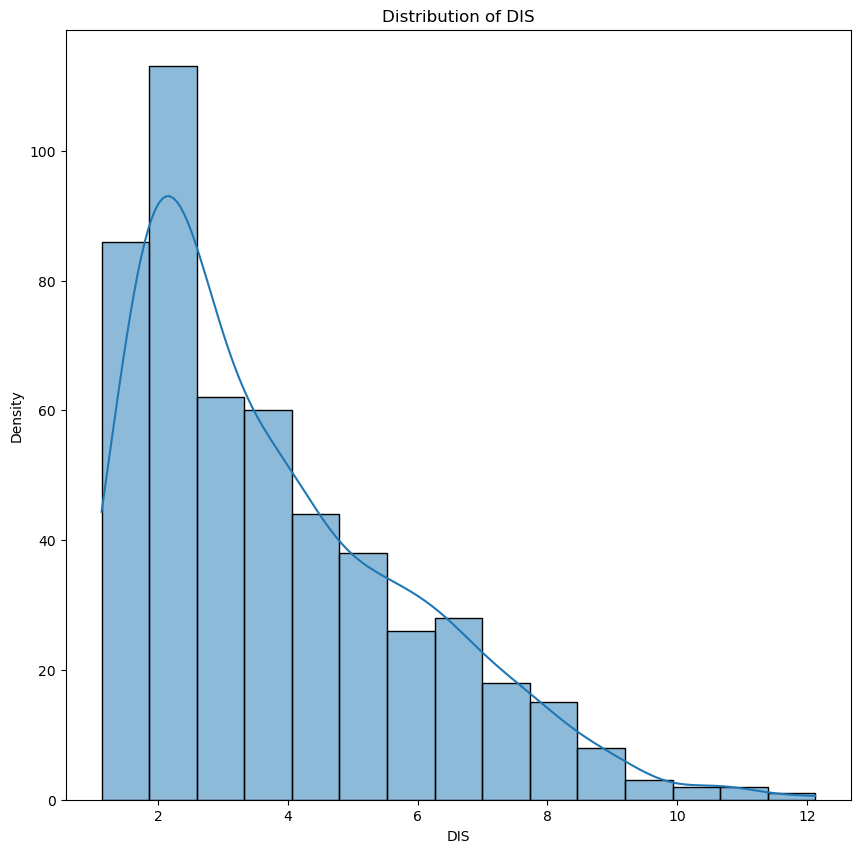

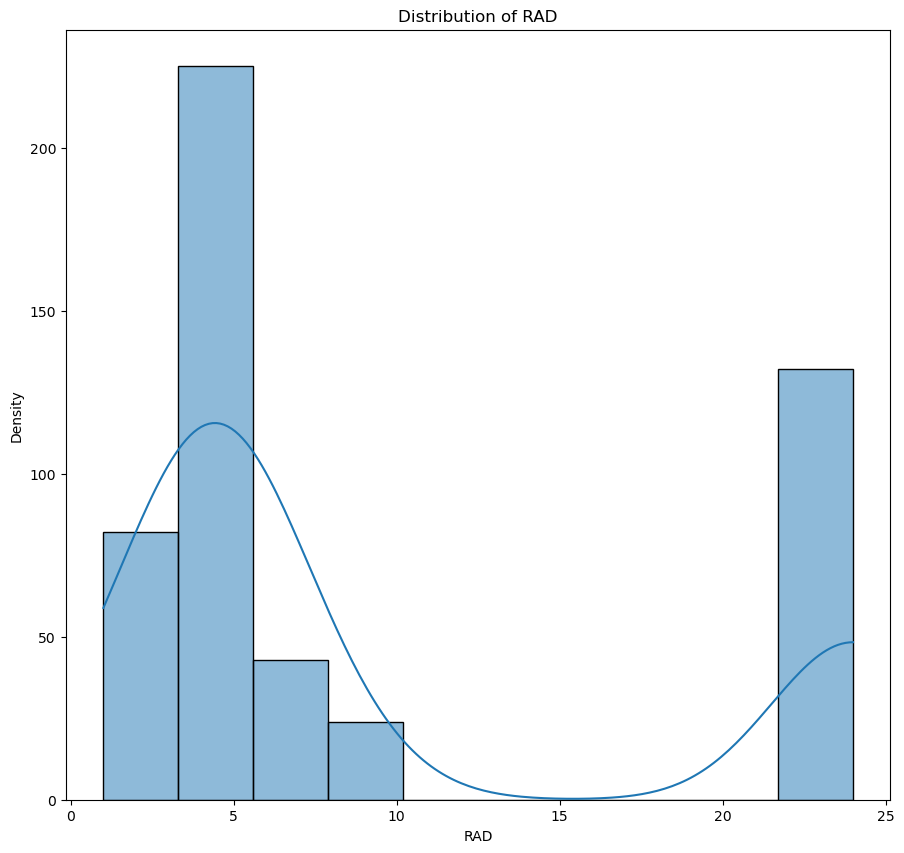

In [41]:
df1 = df[["PRICE","RM", "DIS", "RAD"]]

for column in df1:
    # features
    plt.figure(figsize = (15,10))

    #function
    ax = sns.histplot(data = df1, x= column, kde=True)

    # Extra arguments
    plt.xlabel(column)
    plt.ylabel("Density")
    plt.title(f"Distribution of {column}")
    ax.set_aspect(aspect  = 0.1, adjustable = "box")            # How to stretch the axis

    plt.show()


**Challenge**


Create a bar chart with plotly for CHAS to show many more homes are away from the river versus next to it.



In [42]:
#### Creating the subset for the plot

        ### Problem that python seems the categories as numbers and not names
df["CHAS"] = np.where(df["CHAS"]==1, "Close to River", "Far from River")
subset1 = df["CHAS"].value_counts()
subset1

CHAS
Far from River    471
Close to River     35
Name: count, dtype: int64

In [43]:
### Creating the Graph
fig = px.bar(subset1,
             x= subset1.index,
             y= subset1.values ,
             title= "Number of Houses close to the River",
             color =subset1.index,)
fig.update_layout(xaxis_title= "Houses",
           yaxis_title= "Number of Houses close to the River",)
fig.show()

**Challenge**

* What would you expect the relationship to be between pollution (NOX) and the distance to employment (DIS)?
* What kind of relationship do you expect between the number of rooms (RM) and the home value (PRICE)?
* What about the amount of poverty in an area (LSTAT) and home prices?

Run
aSeaborn `.pairplot` to visualise all the relationships at the same time. Note, this is a big task and can take 1-2 minutes! After it's finished check your intuition regarding the questions above on the `pairplot`.

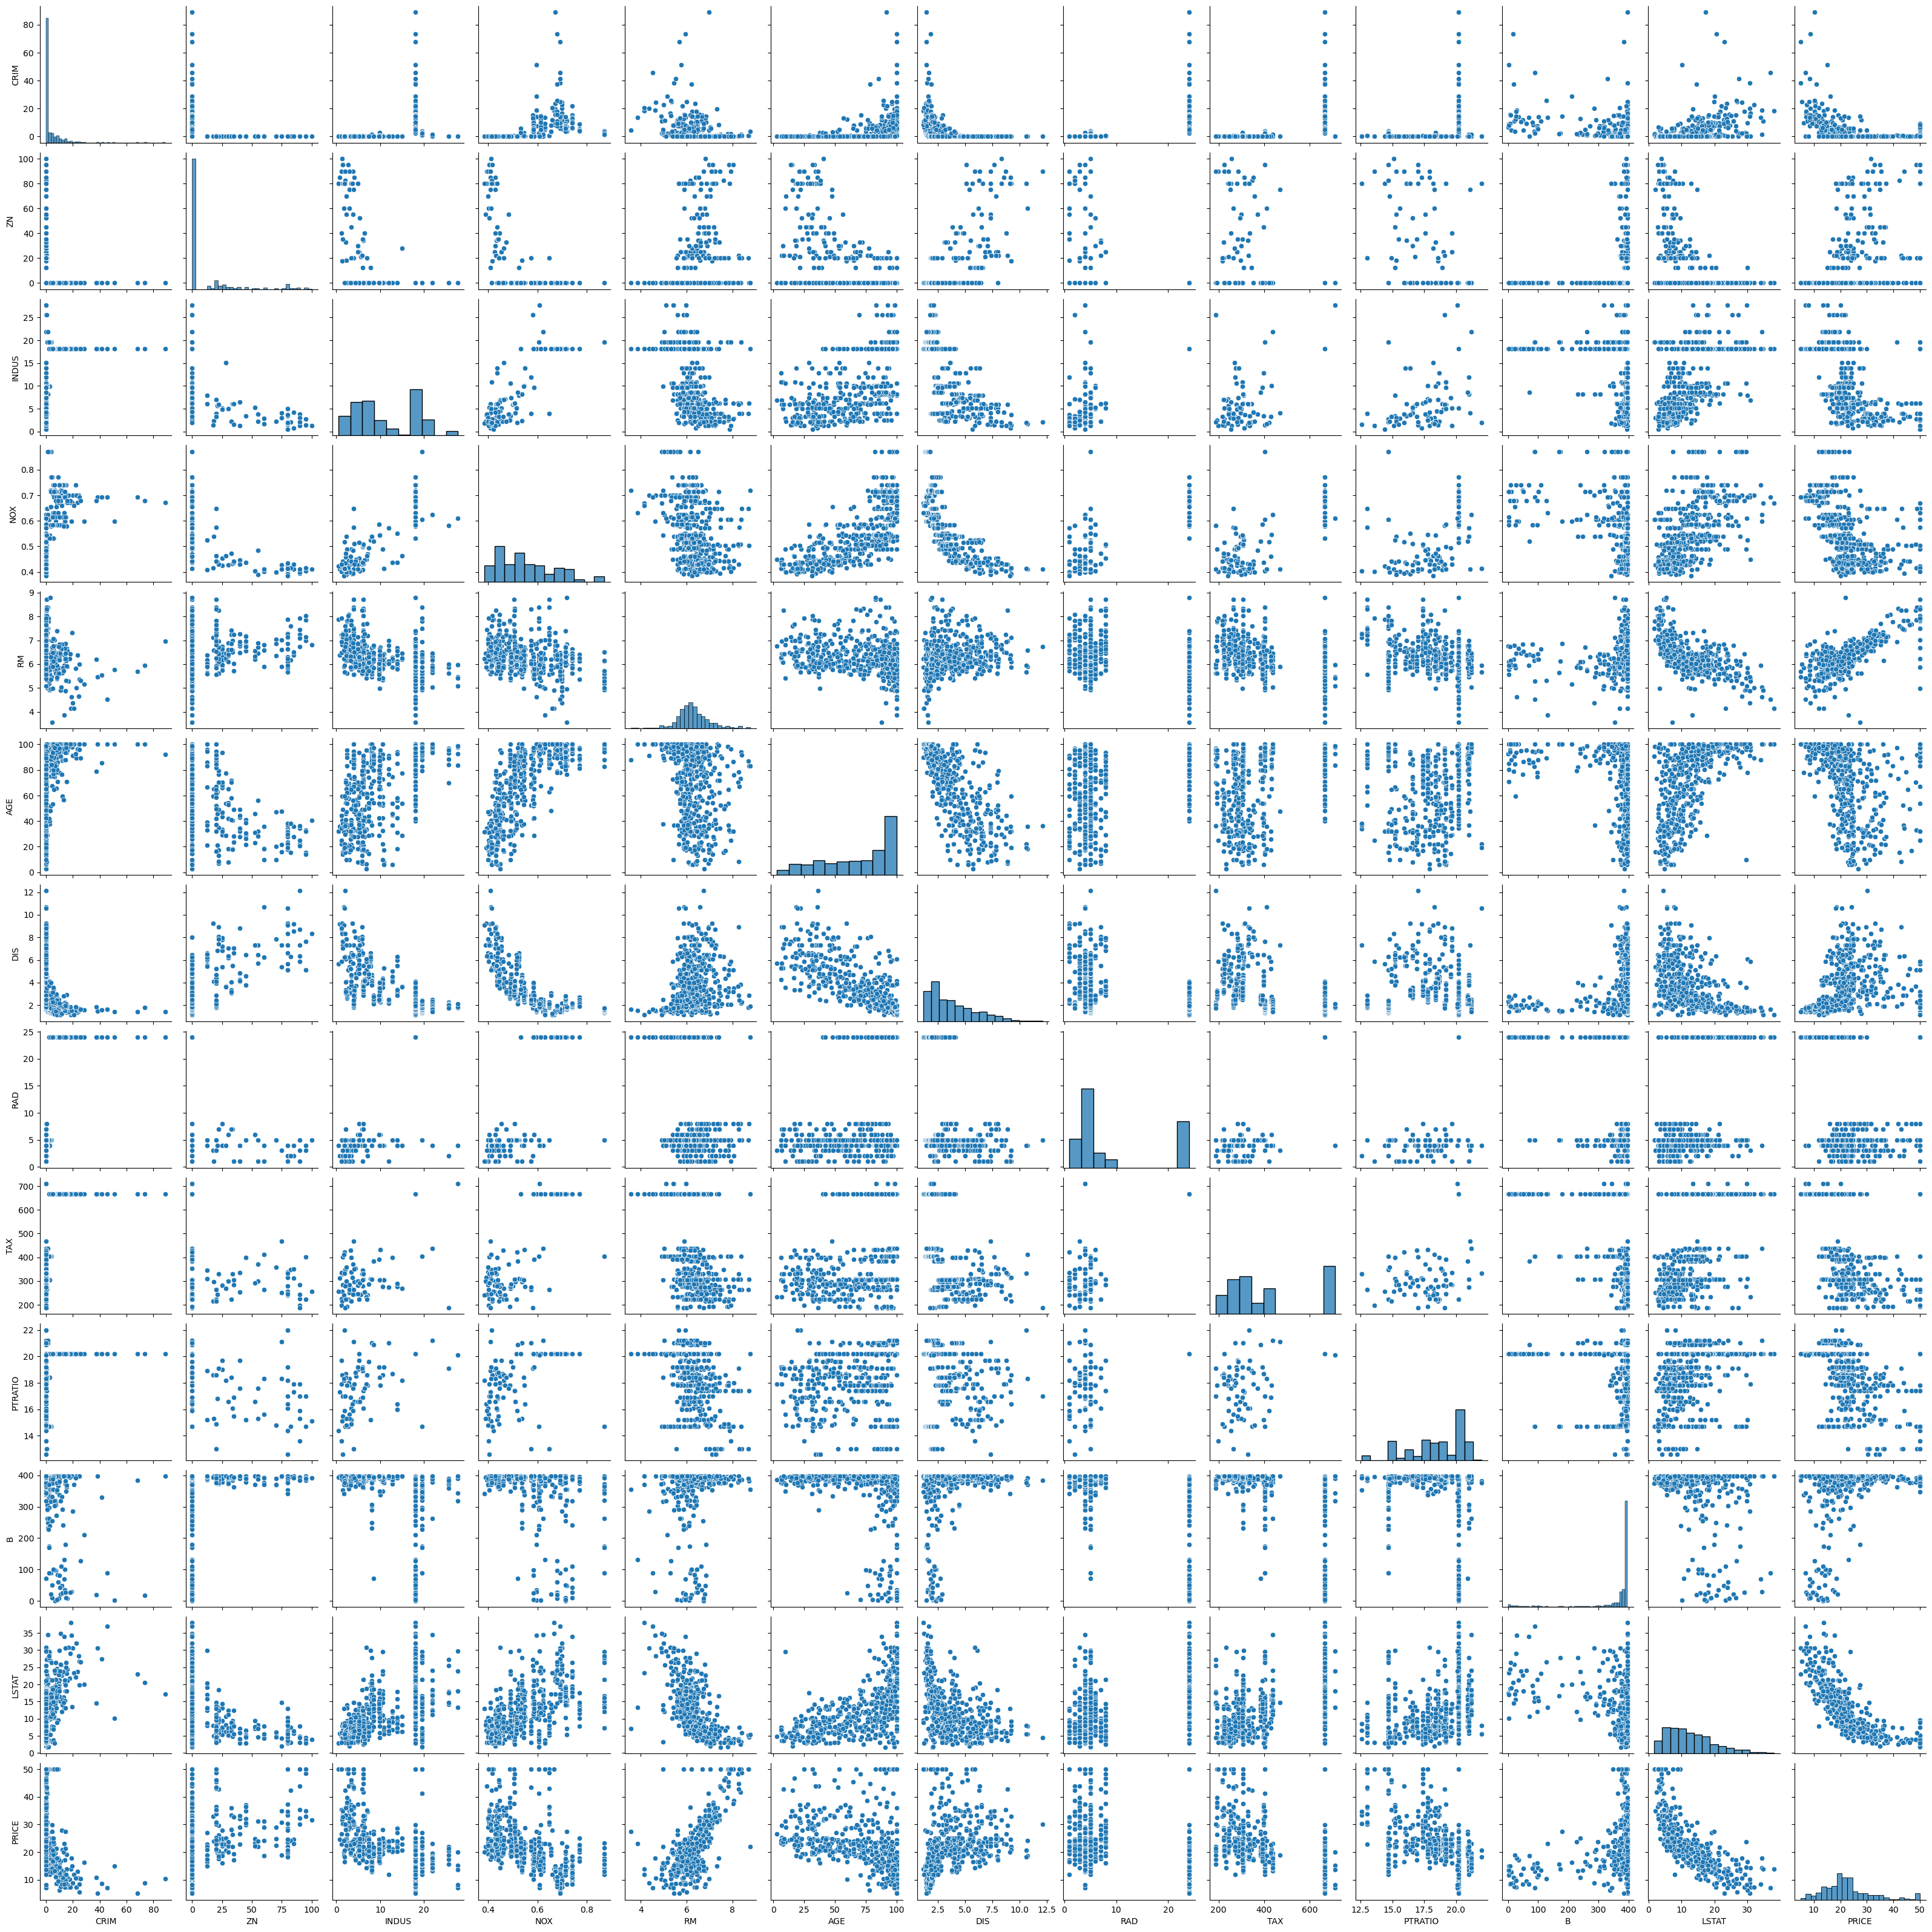

In [44]:
sns.pairplot(df)            ## Pairplots allow you to compare relationships between many things together in mnay ways

#### Distance from Employment vs. Pollution

**Challenge**:

Compare DIS (Distance from employment) with NOX (Nitric Oxide Pollution) using Seaborn's `.jointplot()`. Does pollution go up or down as the distance increases?

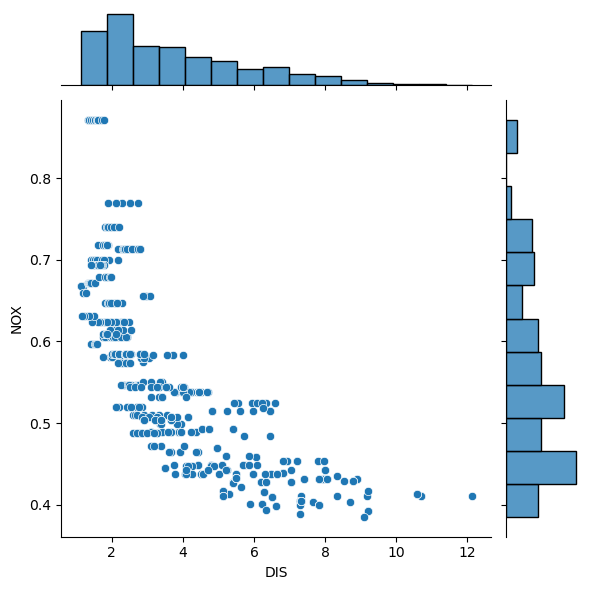

In [45]:
chart = sns.jointplot(data= df,
                      x="DIS",
                      y="NOX",
                      kind= "scatter",)

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

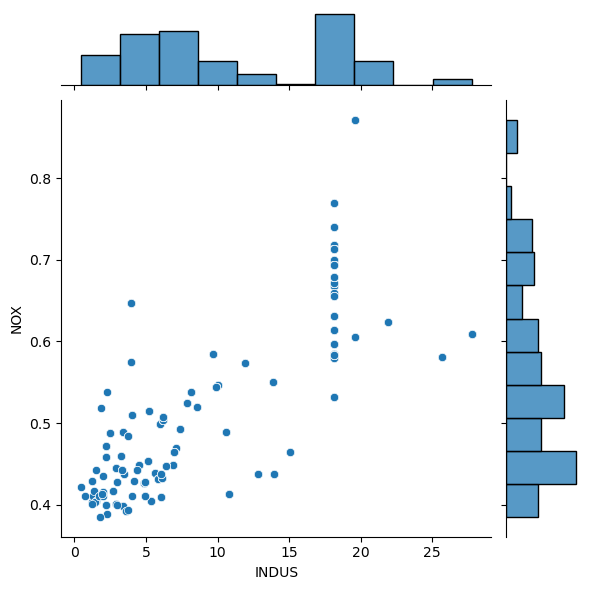

In [46]:
chart = sns.jointplot(data= df,
                      x="INDUS",
                      y="NOX",
                      kind= "scatter",)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

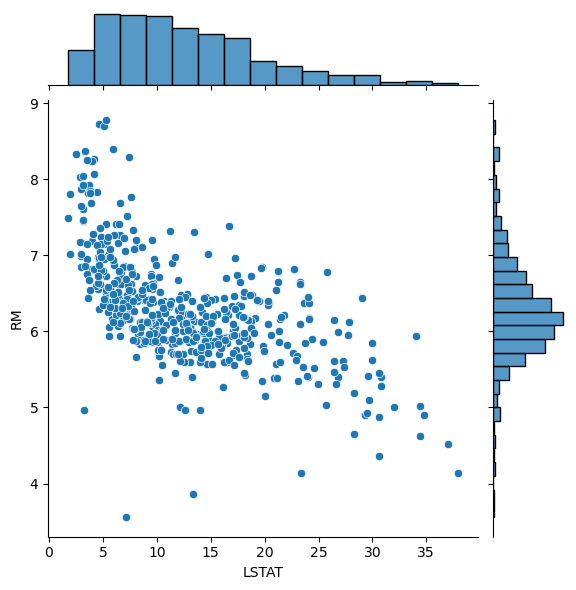

In [47]:
chart = sns.jointplot(data= df,
                      x="LSTAT",
                      y="RM",
                      kind= "scatter",)
plt.show

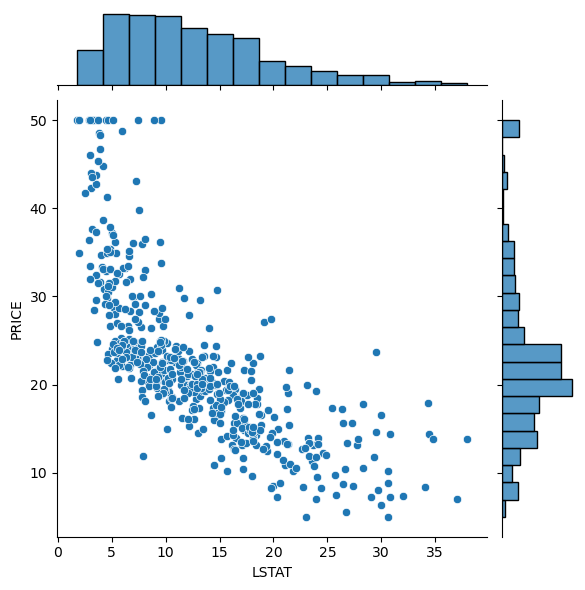

In [48]:
chart = sns.jointplot(data= df,
                      x="LSTAT",
                      y="PRICE",
                      kind= "scatter",)

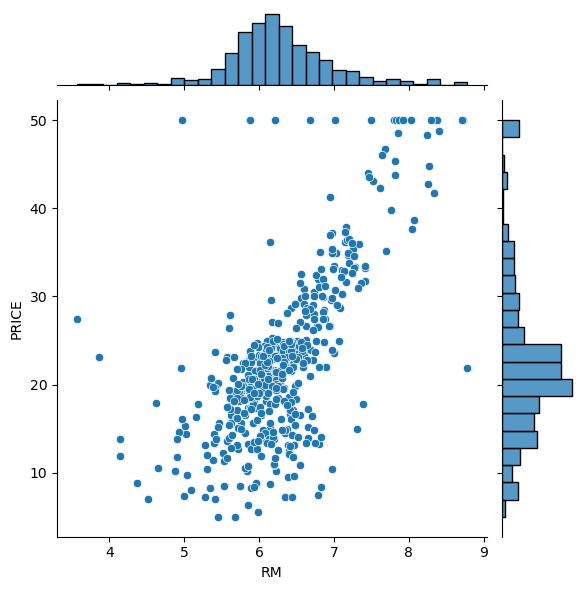

In [49]:
chart = sns.jointplot(data= df,
                      x="RM",
                      y="PRICE",
                      kind= "scatter",)
plt.show()

### Split Training & Test Dataset



We *can't* use all 506 entries in our dataset to train our model. The reason is that we want to evaluate our model on data that it hasn't seen yet (i.e., out-of-sample data). That way we can get a better idea of its performance in the real world.

**Challenge**

* Import the [`train_test_split()` function](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) from sklearn
* Create 4 subsets: X_train, X_test, y_train, y_test
* Split the training and testing data roughly 80/20.
* To get the same random split every time you run your notebook use `random_state=10`. This helps us get the same results every time and avoid confusion while we're learning.


Hint: Remember, your **target** is your home PRICE, and your **features** are all the other columns you'll use to predict the price.

In [50]:
### Need to conver far from river into a float
    ### In this case one cvan convert it back  using the same code as before
    ### But will drop it in this case for ease

In [51]:
X = df.drop(["PRICE","CHAS"], axis=1)            # All columsn except for price
y = df["PRICE"]                         # All columns for price


## Machine elarning pipleine:
X_train, X_test,  Y_train, Y_test= train_test_split( X,y, test_size= 0.2, random_state= 10)            # This line sets the stage for the entire process
                                                                                                        # X_TRAIN= FEATURES THE MODEL LEARNS FROM
                                                                                                        # Y_TRAIN PRICES THE MODEL LEARNS TO PREDICT
                                                                                                        # XTEST = NEW UNSEEN FEATURES
                                                                                                        # YTEST USED TO EVLAUTE THE MODEL
                                                                                                            ### THE ORFDER OF THESE MUST STAY THE SAME BUT CAN CHAGE NAMES
                                                                                                        # X IS THE THING THAT YOU USE
                                                                                                        # Y IS THE THING YOU ARE PREDICTING
                                                                                                        # TEST SIZE = 2-%
                                                                                                        # RANDOMS STATE == USE THIS SPECIFIC SEED( WHERE THE SHUFFLE BEGINS) TO GET THE SAME RANDOMORDER
regressor = LinearRegression()                                                                          # Model object
regressor.fit(X_train, Y_train)                                                                         # Looks at 80 percnet of the data aand finds the fit?
predictions = regressor.predict(X_test)                                                                 ## This will becoem a numpy array for the values tested for the row combination of xtest


## To compare the predictions
comparisons = pd.DataFrame({"Actual": Y_test.values, "Predicted": predictions})
comparisons.head(20)

,Actual,Predicted
0,28.40,31.26
1,31.10,31.76
2,23.50,30.89
3,26.60,22.19
4,19.60,19.28
5,14.30,16.60
6,50.00,36.54
7,14.30,14.76
8,20.70,23.37
9,37.60,37.29


### Multivariate Regressions

In [52]:
model1=LinearRegression()
model1.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [63]:
## Getting the coefficients
model1.coef_                ## Lots of columns so lots of vlaues. Can turn them into a table.

coef_df = pd.DataFrame({"Variable":X_train.columns,
                        "Coefficients":model1.coef_,})
coef_df.head(20)

## Getting the intercepts
model1.intercept_               # Intercept is fixed


## Getting the r squared
model1.score(X_train, Y_train)

0.74719302333942

##### Analyse the Estimated Values & Regression Residuals

In [65]:
## Create a set of predicted values;
predicted_values= regressor.predict(X_train)
residuals = (Y_train-predicted_values)

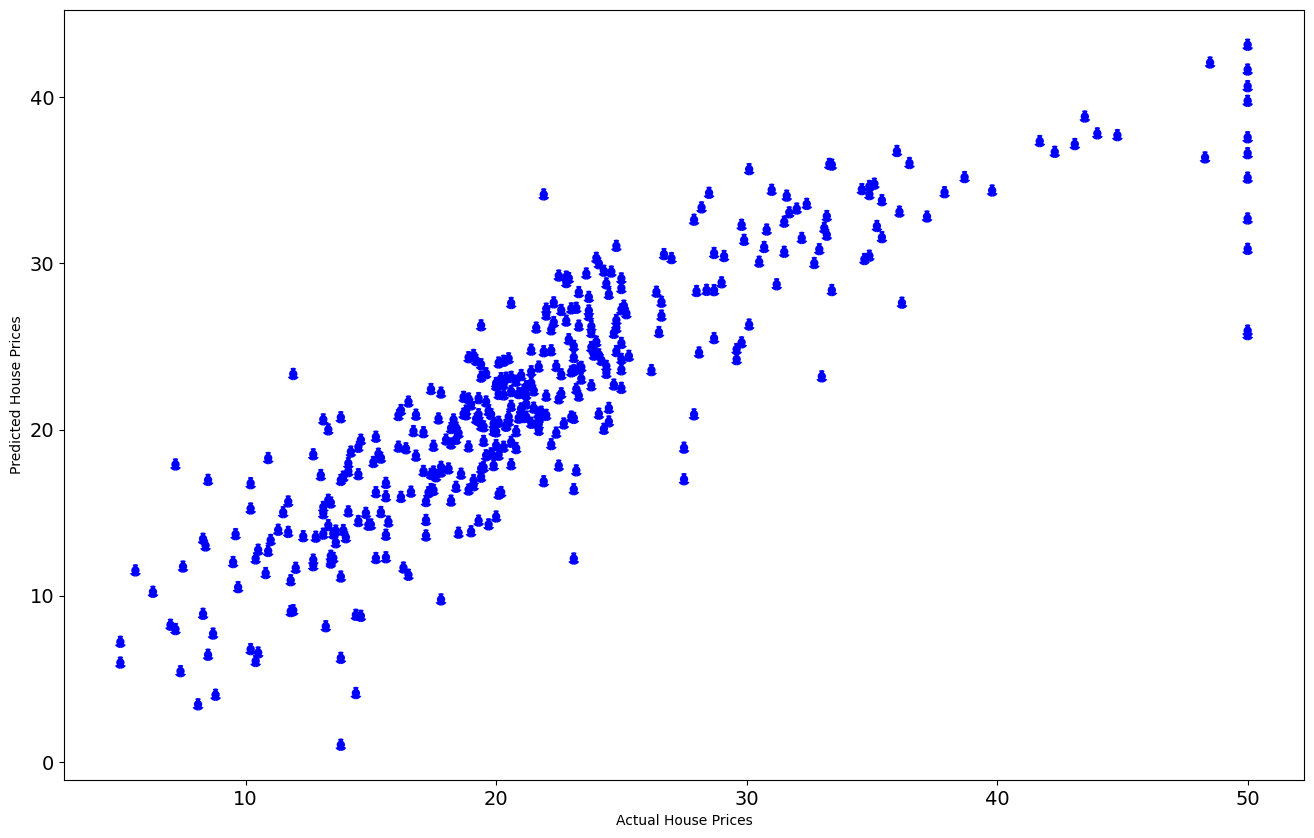

In [69]:
### Drawing out the predicted prices versus the actual prices

    # Setting it up
plt.figure(figsize =(16,10))
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)

chart1= plt.scatter(x= Y_train,
                    y= predicted_values,
                    color="blue",
                    linewidths=3,
                    linestyles =":")

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual House prices versus Predicted House Prices")
plt.show()

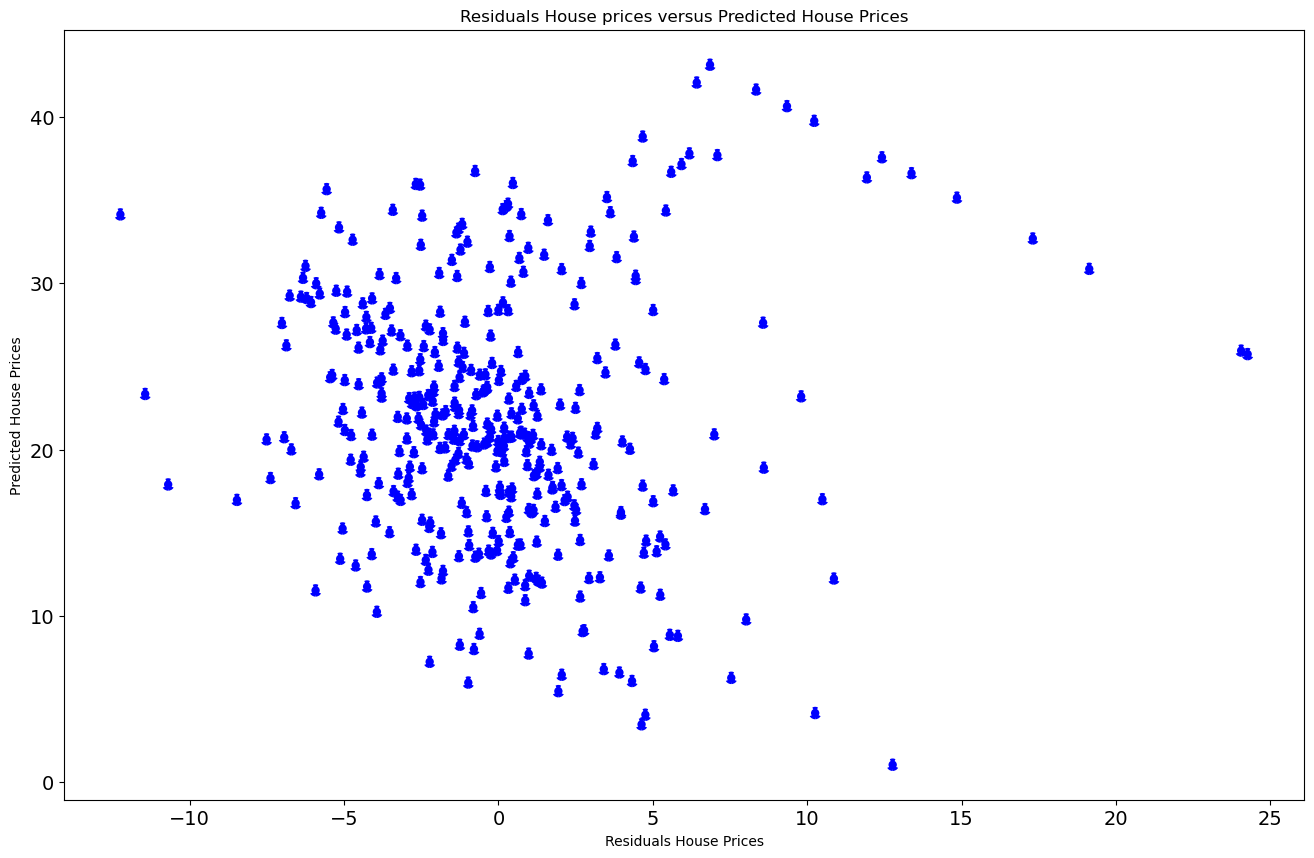

In [70]:
### Drawing out the predicted prices versus the actual prices

    # Setting it up
plt.figure(figsize =(16,10))
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)

chart1= plt.scatter(x= residuals,
                    y= predicted_values,
                    color="blue",
                    linewidths=3,
                    linestyles =":")

plt.xlabel("Residuals House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Residuals House prices versus Predicted House Prices")
plt.show()

Why do we want to look at the residuals? We want to check that they look random. Why? The residuals represent the errors of our model. If there's a pattern in our errors, then our model has a systematic bias.

We can analyse the distribution of the residuals. In particular, we're interested in the **skew** and the **mean**.

In an ideal case, what we want is something close to a normal distribution. A normal distribution has a skewness of 0 and a mean of 0. A skew of 0 means that the distribution is symmetrical - the bell curve is not lopsided or biased to one side. Here's what a normal distribution looks like:


**Challenge**

* Calculate the mean and the skewness of the residuals.
* Again, use Seaborn's `.displot()` to create a histogram and superimpose the Kernel Density Estimate (KDE)
* Is the skewness different from zero? If so, by how much?
* Is the mean different from zero?

In [71]:
residuals.mean()

np.float64(-2.365544503953799e-15)

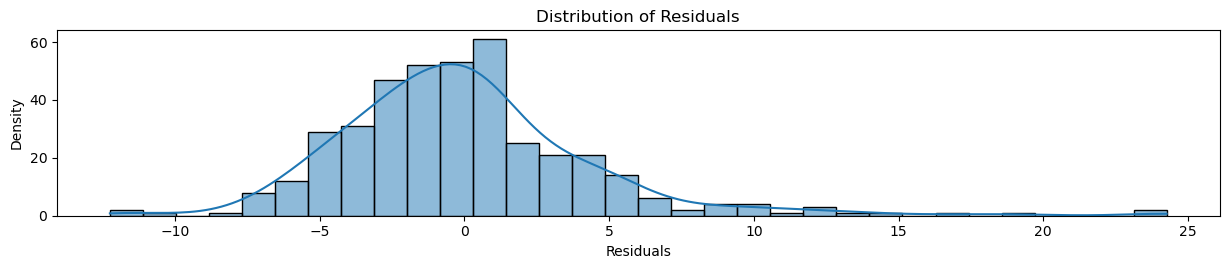

In [74]:
plt.figure(figsize = (15,10))

#function
ax = sns.histplot( x= residuals, kde=True)

# Extra arguments
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.title(f"Distribution of Residuals")
ax.set_aspect(aspect  = 0.1, adjustable = "box")            # How to stretch the axis

plt.show()

### Data Transformations for a Better Fit

We have two options at this point:

1. Change our model entirely. Perhaps a linear model is not appropriate.
2. Transform our data to make it fit better with our linear model.

Let's try a data transformation approach.

**Challenge**

Investigate if the target `data['PRICE']` could be a suitable candidate for a log transformation.

* Use Seaborn's `.displot()` to show a histogram and KDE of the price data.
* Calculate the skew of that distribution.
* Use [NumPy's `log()` function](https://numpy.org/doc/stable/reference/generated/numpy.log.html) to create a Series that has the log prices
* Plot the log prices using Seaborn's `.displot()` and calculate the skew.
* Which distribution has a skew that's closer to zero?

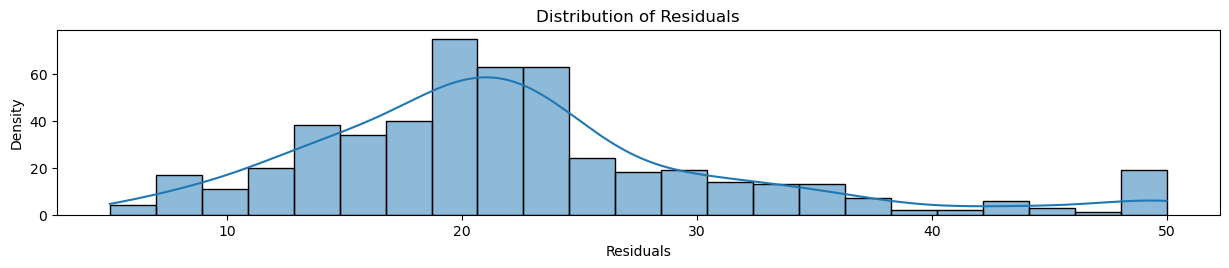

In [75]:
## Histogram and Kernal Distributions
plt.figure(figsize = (15,10))

#function
ax = sns.histplot( x= df["PRICE"], kde=True)

# Extra arguments
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.title(f"Distribution of Residuals")
ax.set_aspect(aspect  = 0.1, adjustable = "box")            # How to stretch the axis

plt.show()

In [77]:
## SKEWNESS
df["PRICE"].skew()

np.float64(1.1080984082549072)

In [81]:
### log Transformations
log_transform = np.log(df["PRICE"])

0     3.18
1     3.07
2     3.55
3     3.51
4     3.59
      ... 
501   3.11
502   3.03
503   3.17
504   3.09
505   2.48
Name: PRICE, Length: 506, dtype: float64

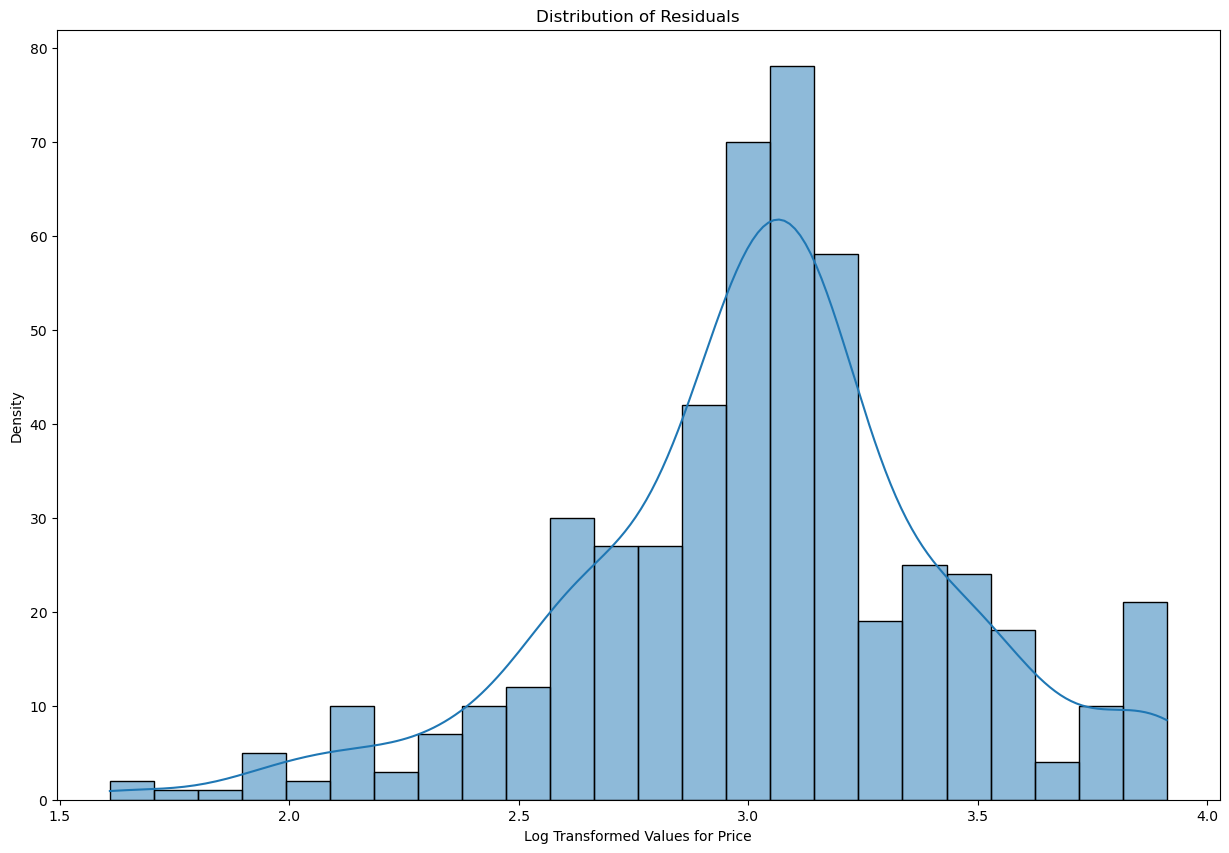

In [83]:
### Plotting the log Tranform function

plt.figure(figsize = (15,10))

#function
ax = sns.histplot( x= log_transform, kde=True)

# Extra arguments
plt.xlabel("Log Transformed Values for Price")
plt.ylabel("Density")
plt.title(f"Distribution of Residuals")


plt.show()

### Regression using Log Prices

In [95]:
## Setting the variables
X = df.drop(["PRICE","CHAS"], axis=1)           ## Look at everything except for these two
Y= log_transform.values

## Setting up the tests
X_logtrain, Y_logtrain, X_logtest, Y_logtest = train_test_split(X,Y, test_size= 0.2, random_state= 10 )


## Running the models
model2 = LinearRegression()
model2.fit(X_train, Y_train)
predictions = model2.predict(X_test)

# Creating the final dataframe
predicted_dataset = pd.DataFrame({"Actual_Log_Prices":Y_logtest, "Predicted_Prices":predictions})
predicted_dataset.head(20)


,Actual_Log_Prices,Predicted_Prices
0,3.35,31.26
1,3.44,31.76
2,3.16,30.89
3,3.28,22.19
4,2.98,19.28
5,2.66,16.60
6,3.91,36.54
7,2.66,14.76
8,3.03,23.37
9,3.63,37.29


In [99]:
## Calculating the r squared on the predicted data
predicted_dataset["Predicted_Prices"].skew()


## Calucate the coefficients:
coefficients_dataset  = pd.DataFrame({"Column_Names":X.columns, "Coefficients":model2.coef_, })

## Calcuate the intercepts
model2.intercept_

np.float64(36.62664447409222)